# Weather benchmark: 2. Descriptive analysis of the reference table

This notebook describes the completed Weather benchmark. It does not fit or evaluate the adaptive selector. Its role is to make benchmark composition and the method-outcome landscape transparent before confirmatory evaluation.


## Interpretation and estimand

For each artificial gap, the *offline oracle* is the registered candidate method with the lowest realised locally normalised RMSE (nRMSE). It describes outcome heterogeneity, but it is not deployable because it uses the concealed gap truth.

For Weather, nRMSE is normalised by the local context scale with the fold-appropriate positive IQR floor. Lower nRMSE values are better. The adaptive selector is assessed only on held-out stations in notebook 3.


In [1]:
from pathlib import Path
import os
import sys
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'pyproject.toml').is_file():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError('Start Jupyter from inside the repository.')
    PROJECT_ROOT = PROJECT_ROOT.parent

source_root = str(PROJECT_ROOT / 'src')
if source_root not in sys.path:
    sys.path.insert(0, source_root)
import matplotlib.pyplot as plt
import pandas as pd
from gap_imputation_benchmark.domains.weather import WEATHER_DOMAIN
from gap_imputation_benchmark.evaluation import (
    plot_mean_method_error, plot_oracle_distribution, plot_oracle_frequency,
)
from gap_imputation_benchmark.paths import load_local_environment, local_path_or_default
load_local_environment(override=True)

if not os.environ.get('WEATHER_DATA_DIR'):
    raise RuntimeError("Set WEATHER_DATA_DIR in .env or in the current session.")

DATA_DIR = Path(os.environ['WEATHER_DATA_DIR'])
BENCHMARK_DIR = local_path_or_default(
    'WEATHER_BENCHMARK_DIR', PROJECT_ROOT / 'benchmarks' / 'weather',
)
gaps = pd.read_csv(BENCHMARK_DIR / 'learnable_gap_table.csv')
coverage = pd.read_csv(BENCHMARK_DIR / 'coverage_table.csv')
METHODS = tuple(WEATHER_DOMAIN.methods)
METHOD_LABELS = WEATHER_DOMAIN.method_labels
ORACLE_COLUMN = 'best_method_by_nrmse'
assert gaps['gap_id'].is_unique
assert gaps[ORACLE_COLUMN].isin(METHODS).all()
print(f'{len(gaps):,} learnable gaps; {gaps["station_id"].nunique()} station_id groups')


8,283 learnable gaps; 16 station_id groups


/var/folders/lp/fgbgpy6n6d72_4fqh9dndn0w0000gn/T/ipykernel_47413/1072226561.py:29: DtypeWarning: Columns (0: template_failure_reason, 1: seasonal_periodic_failure_reason) have mixed types. Specify dtype option on import or set low_memory=False.
  gaps = pd.read_csv(BENCHMARK_DIR / 'learnable_gap_table.csv')


## Benchmark coverage and sampling balance

Coverage is aggregated by station, the outer evaluation unit. The table shows both requested and successful gaps; a non-zero `shortfall` or `excluded_gaps` value records a failure of the fixed eligibility rule rather than a silent protocol change.


,dataset_id,requested_gaps,learnable_gaps,excluded_gaps
0,232,520,519,1
1,427,520,519,1
2,1048,520,520,0
3,1346,520,517,3
4,1420,520,516,4
5,1443,520,519,1
6,1550,520,517,3
7,1691,520,516,4
8,1975,520,518,2
9,2014,520,519,1


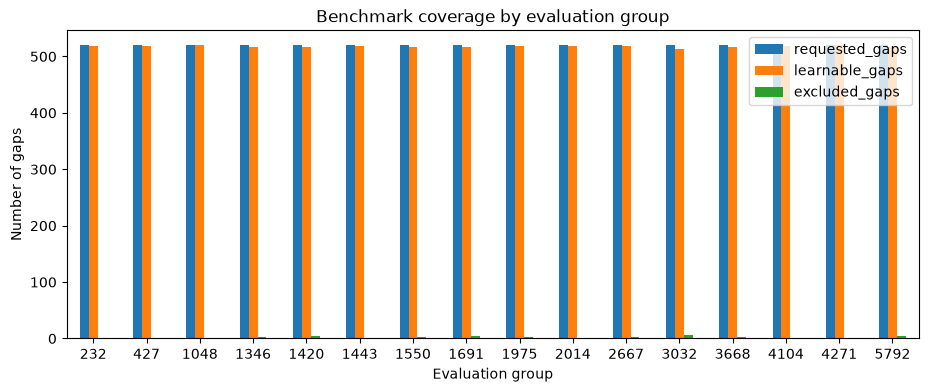

In [2]:
if 'weather' == 'weather':
    coverage_plot = (
        coverage.groupby('station_id', as_index=False)[['requested_gaps', 'successful_gaps', 'shortfall']]
        .sum()
        .rename(columns={'station_id': 'dataset_id', 'successful_gaps': 'learnable_gaps', 'shortfall': 'excluded_gaps'})
    )
else:
    coverage_plot = (
        coverage.groupby('district', as_index=False)[['n_gaps_requested', 'n_gaps_written', 'shortfall']]
        .sum()
        .rename(columns={'district': 'dataset_id', 'n_gaps_requested': 'requested_gaps', 'n_gaps_written': 'learnable_gaps', 'shortfall': 'excluded_gaps'})
    )

display(coverage_plot)
ax = coverage_plot.set_index('dataset_id')[['requested_gaps', 'learnable_gaps', 'excluded_gaps']].plot(
    kind='bar', figsize=(11, 4), title='Benchmark coverage by evaluation group',
    xlabel='Evaluation group', ylabel='Number of gaps', rot=0,
)
plt.show()


## Offline-oracle patterns

The overall chart shows which method is most often best in retrospect. The station-level view is a diagnostic for domain shift; the duration-stratum view shows how preferred methods vary with gap length.

These summaries are descriptive results for artificial gaps. They are not estimates of the performance of the trained selector or of real missing intervals.


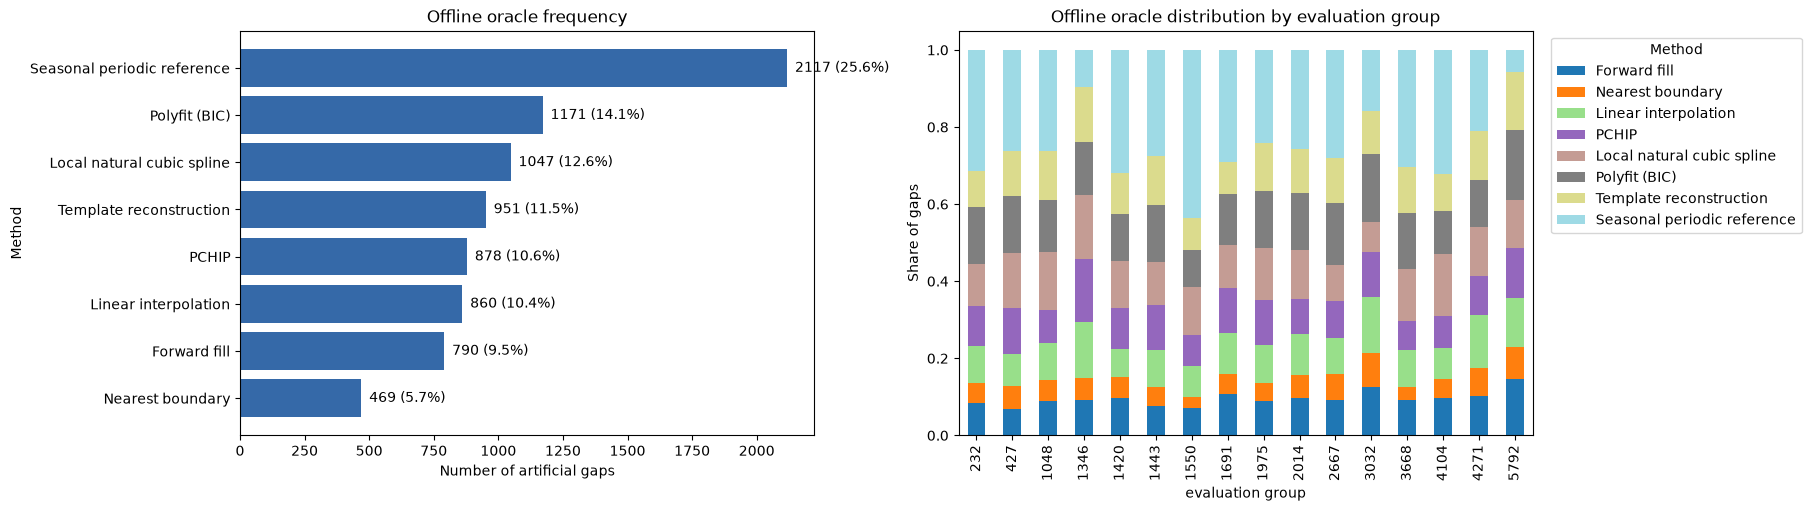

best_method_by_nrmse,forward_fill,nearest_boundary,linear,pchip,local_natural_cubic_spline,polyfit_bic,template,seasonal_periodic
station_id,,,,,,,,
232,8.5,5.0,9.6,10.4,11.0,14.8,9.2,31.4
427,6.7,6.2,8.1,11.9,14.3,15.0,11.6,26.2
1048,9.0,5.4,9.4,8.7,15.0,13.5,12.7,26.3
1346,9.3,5.6,14.5,16.2,16.6,13.7,14.3,9.7
1420,9.7,5.4,7.4,10.5,12.4,12.0,10.7,32.0
1443,7.5,5.0,9.6,11.8,11.0,14.8,12.7,27.6
1550,7.2,2.7,8.1,8.1,12.4,9.7,8.3,43.5
1691,10.7,5.2,10.7,11.6,11.2,13.2,8.3,29.1
1975,8.9,4.8,9.8,11.6,13.5,14.9,12.4,24.1


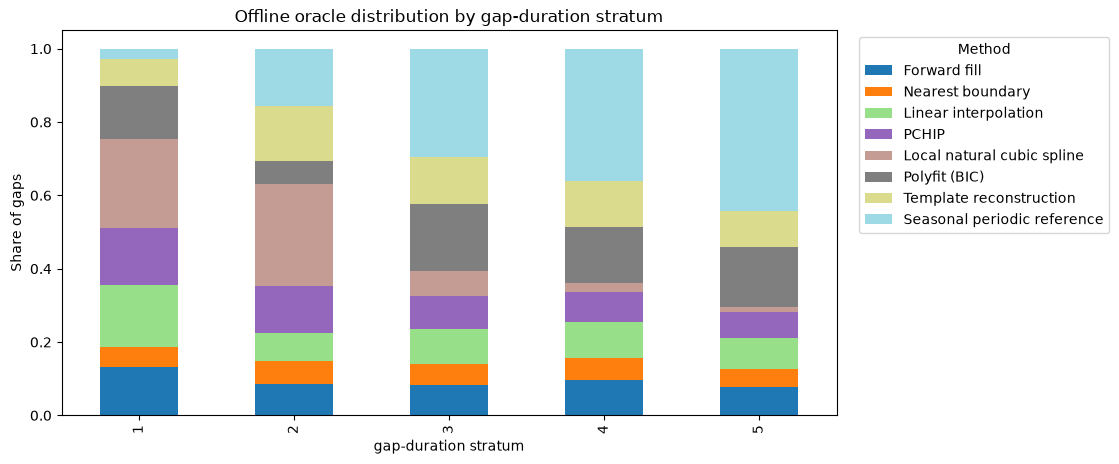

best_method_by_nrmse,forward_fill,nearest_boundary,linear,pchip,local_natural_cubic_spline,polyfit_bic,template,seasonal_periodic
duration_stratum,,,,,,,,
1,13.2,5.5,16.7,15.6,24.5,14.5,7.2,2.8
2,8.7,6.2,7.5,13.0,27.7,6.3,15.1,15.5
3,8.4,5.7,9.4,9.0,7.0,18.2,12.7,29.6
4,9.6,5.9,9.9,8.2,2.5,15.2,12.5,36.1
5,7.8,4.9,8.3,7.2,1.2,16.5,9.8,44.2


In [3]:
group_column = 'station_id'
fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
plot_oracle_frequency(gaps, METHODS, oracle_column=ORACLE_COLUMN, method_labels=METHOD_LABELS, ax=axes[0])
_, oracle_by_group = plot_oracle_distribution(
    gaps, METHODS, group_column=group_column, oracle_column=ORACLE_COLUMN,
    method_labels=METHOD_LABELS, group_label='evaluation group', ax=axes[1],
)
plt.show()
display((100 * oracle_by_group).round(1))

_, oracle_by_duration = plot_oracle_distribution(
    gaps, METHODS, group_column='duration_stratum', oracle_column=ORACLE_COLUMN,
    method_labels=METHOD_LABELS, group_label='gap-duration stratum',
)
plt.show()
display((100 * oracle_by_duration).round(1))


## Mean candidate-method error by station

The final plot compares mean per-gap nRMSE of every candidate method within each station. It complements oracle frequency: a method can rarely be oracle-best and still have stable average error.

No selector is trained in this notebook, so no training and test observations are mixed for a model estimate.


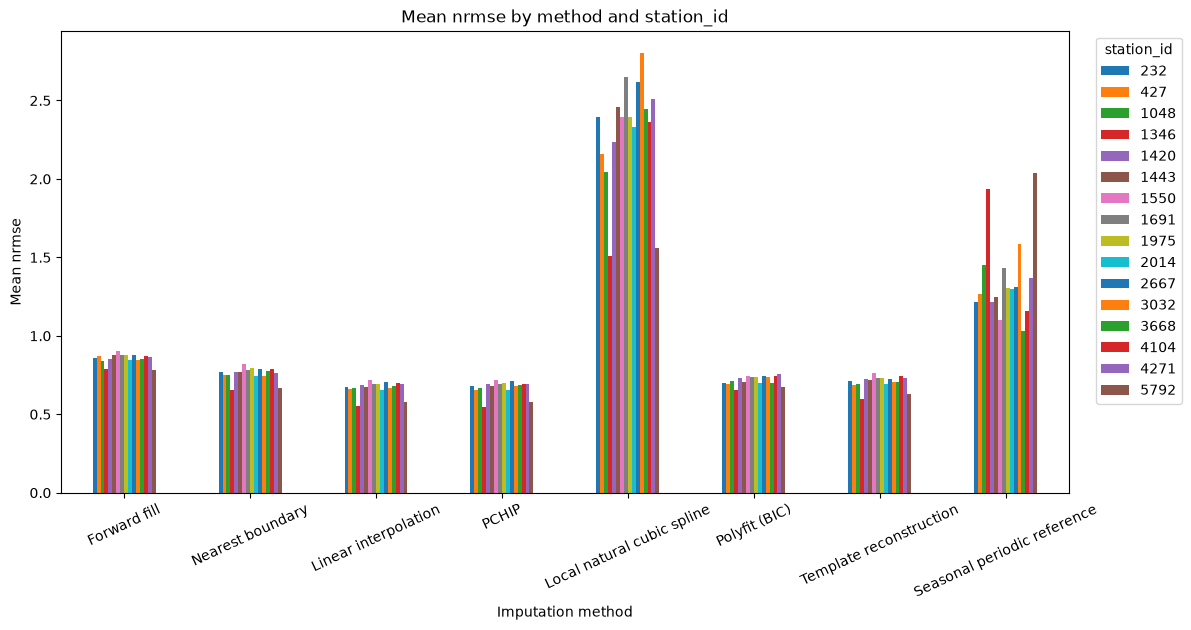

station_id,232,427,1048,1346,1420,1443,1550,1691,1975,2014,2667,3032,3668,4104,4271,5792
Forward fill,0.8585,0.8711,0.8386,0.7890,0.8510,0.8753,0.9049,0.8773,0.8806,0.8486,0.8790,0.8467,0.8510,0.8706,0.8649,0.7822
Nearest boundary,0.7693,0.7530,0.7529,0.6515,0.7666,0.7673,0.8216,0.7844,0.7929,0.7449,0.7912,0.7451,0.7762,0.7865,0.7644,0.6647
Linear interpolation,0.6744,0.6626,0.6671,0.5543,0.6895,0.6750,0.7171,0.6911,0.6927,0.6532,0.7080,0.6689,0.6791,0.7020,0.6913,0.5755
PCHIP,0.6812,0.6568,0.6683,0.5475,0.6898,0.6772,0.7187,0.6904,0.6980,0.6540,0.7142,0.6794,0.6884,0.6952,0.6959,0.5798
Local natural cubic spline,2.3964,2.1582,2.0430,1.5082,2.2385,2.4579,2.3943,2.6506,2.3933,2.3305,2.6204,2.8046,2.4439,2.3618,2.5122,1.5598
Polyfit (BIC),0.6968,0.6931,0.7089,0.6527,0.7302,0.7073,0.7422,0.7348,0.7355,0.6978,0.7429,0.7350,0.6963,0.7471,0.7542,0.6718
Template reconstruction,0.7139,0.6895,0.6961,0.5949,0.7230,0.7162,0.7608,0.7331,0.7289,0.6957,0.7276,0.7050,0.7081,0.7451,0.7340,0.6312
Seasonal periodic reference,1.2130,1.2669,1.4505,1.9357,1.2131,1.2485,1.1002,1.4324,1.3040,1.2954,1.3115,1.5843,1.0311,1.1576,1.3705,2.0408


In [4]:
_, mean_errors = plot_mean_method_error(
    gaps, METHODS, group_column=group_column, method_labels=METHOD_LABELS,
)
plt.show()
display(mean_errors.round(4))
